In [ ]:
import os
from typing import List
from pydantic import BaseModel
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from langchain_core.documents import Document
from langchain_ollama import ChatOllama, OllamaEmbeddings

In [2]:
doc=WebBaseLoader("https://ocw.mit.edu/courses/6-006-introduction-to-algorithms-spring-2020/pages/syllabus/").load()

In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50,separators=["\n\n", "\n", " ", ""])
docs = splitter.split_documents(doc)

In [4]:
embeddings = OllamaEmbeddings(model="bge-m3:latest")

In [5]:
query = "What is the main contribution of the paper?"
embedding_query = embeddings.embed_query(query)
print("Embedding query:", embedding_query)

Embedding query: [-0.05271999, 0.012459708, -0.050377224, 0.0029168995, -0.00071119994, -0.04795294, 0.012839455, 0.022232488, 0.01437896, -0.0019089958, -0.02094152, 0.018689448, -0.045972805, -0.006621633, -0.049905058, 0.022635994, 0.024374269, -0.048731256, -0.0020724307, 0.017305786, -0.024535805, 0.004983108, 0.0071038506, 0.051741384, 0.03400842, 0.05812575, 0.0047434005, -0.0106676845, -0.014817648, 0.017941456, 0.0010257199, -0.026897788, -0.014973717, -0.0011848853, 0.013981585, -0.015170997, -0.01247469, -0.03434095, -0.0646816, 0.034728188, 0.03979444, -0.03038019, -0.0034325374, -0.03595683, -0.0047383336, -0.04313075, -0.017936302, -0.03258943, 0.007602883, -0.0035816303, 0.011246642, 0.0093510635, 0.024967117, -0.019502068, -0.016790938, 0.014662224, -0.048435897, 0.022395367, -0.06264004, -0.042651538, -0.052104365, -0.0011541796, 0.0027184258, -0.014620072, 0.04581011, 0.060106307, 0.057129733, -0.0060975165, 0.016409175, 0.0076874695, -0.0018106182, 0.0261573, 0.00470

In [6]:
vectorstore = Chroma.from_documents(docs
, embedding=embeddings
, persist_directory="chroma_db"
,collection_name="arxiv_papers")

In [7]:
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [8]:
ret=retriever.invoke("what is Grad in agssignments	Percentages Quiz 1")
print("Retrieved documents:", ret[0].page_content)

Retrieved documents: Assignments



Percentages







Quiz 1



20%






Quiz 2



15%






Quiz 3



10%






Final Exam



35%






Problem Sets



18%






Recitation



2%

















      Course Info
    






            Instructors
            



Prof. Erik Demaine


Dr. Jason Ku


Prof. Justin Solomon






                Departments
              



Electrical Engineering and Computer Science






            As Taught In


In [10]:
llm = ChatOllama(model="llama3.2:3b", temperature=0.2)
llm.invoke("What is the main contribution of the paper?")

AIMessage(content="I don't have any information about a specific paper. Can you please provide more context or details about the paper you're referring to? I'll do my best to help you understand its main contribution.", additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-09-06T12:49:35.3448289Z', 'done': True, 'done_reason': 'stop', 'total_duration': 124214829300, 'load_duration': 69443405900, 'prompt_eval_count': 34, 'prompt_eval_duration': 53467612000, 'eval_count': 41, 'eval_duration': 1252931000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--01a076c2-7738-7450-894b-21b3efd11404-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 41, 'total_tokens': 75})

In [12]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [13]:
# a. Plan sub-questions
def plan_steps(state:RAGCoTState)->RAGCoTState:
    prompt=f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result=llm.invoke(prompt).content
    subqs=[line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_steps":subqs})

In [15]:
# b. Retrieve for each step
def retrieve_per_step(state:RAGCoTState)-> RAGCoTState:
    all_docs=[]
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs": all_docs})


In [16]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

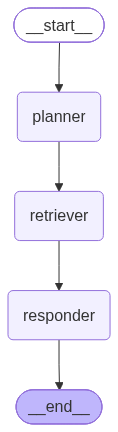

In [17]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------
builder = StateGraph(RAGCoTState)
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [20]:
if __name__ == "__main__":
    query = "Two students work together on Problem Set 4. Student A writes the Python code implementation for an algorithm while Student B watches. Student B then copies the code line-by-line into their submission and cites Student A in their write-up. Does this comply with the 6.006 Collaboration Policy?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ['Here are 2-3 reasoning steps to break down the question:', '**Step 1: Identify the key elements of the Collaboration Policy**', 'The 6.006 Collaboration Policy likely states that students are not allowed to submit work that is substantially copied from another student, and that students must acknowledge the contributions of their collaborators in their submissions. The policy may also specify that students must work together on the problem set, but not submit identical work.', '**Step 2: Analyze the actions of Student A and Student B**', 'Student A writes the Python code implementation for an algorithm, which is a significant contribution to the problem set. Student B then copies the code line-by-line into their submission, without making any significant changes or additions. This suggests that Student B is not contributing their own work, but rather submitting identical code that was written by Student A.', '**Step 3: Determine compliance with the Collaboration P